# Flight Delay Prediction

# Cleaning

In [774]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy import text

flights_data = pd.read_csv('flight_data_2024_sampled.csv')
engine = create_engine('sqlite:///flights.db')
flights_data.to_sql('flights', engine, if_exists='replace', index=False)

head_query = "SELECT * FROM flights LIMIT 10;"
head_flights = pd.read_sql(head_query, engine)
print(head_flights)

with engine.begin() as conn:
    conn.execute(text("""
        ALTER TABLE flights
        ADD COLUMN delay_in_minutes INTEGER;
    """))
    
    conn.execute(text("""
        UPDATE flights
        SET delay_in_minutes = arr_delay + dep_delay
    """))
    
head_flights = pd.read_sql(head_query, engine)

with engine.begin() as conn:
    conn.execute(text("""
        ALTER TABLE flights
        ADD COLUMN IS_Delay BOOL;
    """))
    
    conn.execute(text("""
        UPDATE flights
        SET IS_Delay = CASE 
        WHEN COALESCE(delay_in_minutes,0) >= 10 THEN 1
        ELSE 0
        END;
    """))
    
with engine.begin() as conn:
    conn.execute(text("""
        UPDATE flights
        SET 
            carrier_delay = CASE WHEN IS_Delay = 0 THEN 0 ELSE carrier_delay END,
            weather_delay = CASE WHEN IS_Delay = 0 THEN 0 ELSE weather_delay END,
            nas_delay = CASE WHEN IS_Delay = 0 THEN 0 ELSE nas_delay END,
            security_delay = CASE WHEN IS_Delay = 0 THEN 0 ELSE security_delay END,
            late_aircraft_delay = CASE WHEN IS_Delay = 0 THEN 0 ELSE late_aircraft_delay END;
    """))

with engine.begin() as conn:
    conn.execute(text("""
        ALTER TABLE flights
        ADD COLUMN Season TEXT;
    """))
    
    conn.execute(text("""
        UPDATE flights
        SET Season = CASE WHEN month IN (12, 1, 2) THEN 'Winter'
        WHEN month IN (3, 4, 5) THEN 'Spring'
        WHEN month IN (6, 7, 8) THEN 'Summer'   
        WHEN month IN (9, 10, 11) THEN 'Fall'
        ELSE 'Unknown'
        END;
    """))

with engine.begin() as conn:
    conn.execute(text("""
        ALTER TABLE flights
        ADD COLUMN Departure_Hour INTEGER;
    """))
    
    conn.execute(text("""
        UPDATE flights
        SET Departure_Hour = CASE 
            WHEN Crs_dep_time IS NOT NULL THEN CAST(SUBSTR(printf('%04d', Crs_dep_time), 1, 2) AS INTEGER)
            ELSE NULL
        END;
    """))
    
# USE df (from SQLite) instead of flights_data
df = pd.read_sql("SELECT * FROM flights;", engine)

# 1. Keep only city part (before comma) - now works on df
df['origin_city_name'] = df['origin_city_name'].str.split(',').str[0]
df['dest_city_name'] = df['dest_city_name'].str.split(',').str[0]

# 2. Rename columns
df = df.rename(columns={
    'origin_city_name': 'origin_city',
    'dest_city_name': 'dest_city',
    'origin_state_nm': 'origin_state',
    'dest_state_nm': 'dest_state'
})

df.to_csv('flight_clean.csv', index=False)


   year  month  day_of_month  day_of_week     fl_date op_unique_carrier  \
0  2024      9            13            5  2024-09-13                OO   
1  2024      4             2            2  2024-04-02                DL   
2  2024      6             7            5  2024-06-07                WN   
3  2024      7            31            3  2024-07-31                AA   
4  2024      6            11            2  2024-06-11                WN   
5  2024      3            11            1  2024-03-11                AS   
6  2024     12            13            5  2024-12-13                YX   
7  2024     11            18            1  2024-11-18                AA   
8  2024      4            12            5  2024-04-12                WN   
9  2024      3            26            2  2024-03-26                WN   

   op_carrier_fl_num origin    origin_city_name origin_state_nm  ... diverted  \
0             4314.0    SLC  Salt Lake City, UT            Utah  ...        0   
1           

# Cleaning weather

In [775]:
import pandas as pd
from sqlalchemy import create_engine

weather_df = pd.read_csv('weather_data_sampled.csv')
engine = create_engine('sqlite:///:memory:')
weather_df.to_sql('weather', engine, index=False)

query = """
SELECT 
    Location,
    Date_Time,
    Temperature_C,
    Humidity_pct,
    Precipitation_mm,
    Wind_Speed_kmh,
    strftime('%H', Date_Time) AS Hour,
    strftime('%m', Date_Time) AS Month_Number,
    CASE strftime('%m', Date_Time)
        WHEN '01' THEN 'January'
        WHEN '02' THEN 'February'
        WHEN '03' THEN 'March'
        WHEN '04' THEN 'April'
        WHEN '05' THEN 'May'
        WHEN '06' THEN 'June'
        WHEN '07' THEN 'July'
        WHEN '08' THEN 'August'
        WHEN '09' THEN 'September'
        WHEN '10' THEN 'October'
        WHEN '11' THEN 'November'
        WHEN '12' THEN 'December'
    END AS Month_Name,
    strftime('%d', Date_Time) AS Day_of_Month,
    CASE strftime('%w', Date_Time)
        WHEN '0' THEN 'Sunday'
        WHEN '1' THEN 'Monday'
        WHEN '2' THEN 'Tuesday'
        WHEN '3' THEN 'Wednesday'
        WHEN '4' THEN 'Thursday'
        WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday'
    END AS Weekday
FROM weather;
"""

result = pd.read_sql(query, engine)
result.to_csv('weather_clean.csv', index=False)

# Joining the data

In [776]:
import pandas as pd

file_path = "flight_clean.csv"
weather_path = "weather_clean.csv"
output_path = "merged_flights.csv"


def drop_duplicate_columns(df):
    seen = {}
    cols_to_drop = []

    for col in df.columns:
        base = col.lower().rstrip("_xy").rstrip("_")
        if base in seen:
            cols_to_drop.append(col)
        else:
            seen[base] = col

    if cols_to_drop:
        print(f"Dropping duplicate columns: {cols_to_drop}")
        df = df.drop(columns=cols_to_drop)

    return df


def perform_merge(flights, weather):
    flights = flights.dropna(subset=['Departure_Hour'])
    
    flights["fl_datetime"] = pd.to_datetime(flights["fl_date"]) + pd.to_timedelta(flights["Departure_Hour"], unit="h")
    
    flights = flights.dropna(subset=["fl_datetime"])
    # Build proper datetime for flights: fl_date + Departure_Hour
    # e.g. 2024-01-04 + hour 9 -> 2024-01-04 09:00:00
    flights["fl_datetime"] = pd.to_datetime(flights["fl_date"]) + pd.to_timedelta(flights["Departure_Hour"], unit="h")

    weather["Date_Time"] = pd.to_datetime(weather["Date_Time"])

    # Sort for merge_asof
    flights = flights.sort_values("fl_datetime").reset_index(drop=True)
    weather = weather.sort_values("Date_Time").reset_index(drop=True)

    # Rename weather location to match flights origin_city
    weather_renamed = weather.rename(columns={"Location": "origin_city"})
    weather_cols = [c for c in weather.columns if c not in ["Location", "Date_Time"]]

    merged_parts = []

    for city, flight_group in flights.groupby("origin_city"):
        weather_group = weather_renamed[weather_renamed["origin_city"] == city].copy()

        if weather_group.empty:
            for col in weather_cols:
                flight_group[col] = None
            flight_group["Date_Time"] = pd.NaT
            merged_parts.append(flight_group)
            continue

        merged_city = pd.merge_asof(
            flight_group.sort_values("fl_datetime"),
            weather_group.sort_values("Date_Time"),
            left_on="fl_datetime",
            right_on="Date_Time",
            by="origin_city",
            direction="nearest",
            tolerance=pd.Timedelta("3H")
        )
        merged_parts.append(merged_city)

    merged = pd.concat(merged_parts, ignore_index=True)

    # Add Weather_Data_Present column based on whether Date_Time was matched
    merged["Weather_Data_Present"] = merged["Date_Time"].notna().map({True: "Yes", False: "No"})

    # Drop duplicate columns
    merged = drop_duplicate_columns(merged)

    # Drop Date_Time and fl_datetime (temp column) from final output
    drop_cols = [c for c in ["Date_Time", "fl_datetime"] if c in merged.columns]
    merged = merged.drop(columns=drop_cols)

    # Drop true duplicate flight rows
    merged = merged.drop_duplicates(
        subset=["fl_date", "op_unique_carrier", "op_carrier_fl_num"], keep="first"
    )

    # Restore original row order
    merged = merged.sort_values("fl_date").reset_index(drop=True)

    return merged



print("Loading data...")
flights = pd.read_csv("flight_clean.csv")
weather = pd.read_csv("weather_clean.csv")
flights['Departure_Hour'] = (flights['dep_time'] // 100).astype('Int64')
flights['Departure_Hour'] = (flights['dep_time'] // 100).astype('Int64')

# Handle missing dep_time
flights_with_departure = flights.dropna(subset=['dep_time']).copy()
flights_with_departure['Departure_Hour'] = (flights_with_departure['dep_time'] // 100).astype(int)

# Or keep NAs:
flights['Departure_Hour'] = (flights['dep_time'] // 100).astype('Int64')
print(f"Flights loaded:  {len(flights):,} rows")
print(f"Weather loaded:  {len(weather):,} rows")

print("Merging...")
merged = perform_merge(flights, weather)

print(f"Merged result:   {len(merged):,} rows")
print(f"Columns in output ({len(merged.columns)}): {list(merged.columns)}")
print(f"Rows with weather matched:    {(merged['Weather_Data_Present'] == 'Yes').sum():,}")
print(f"Rows with no weather match:   {(merged['Weather_Data_Present'] == 'No').sum():,}")


#merged['Temperature_C'] = merged['Temperature_C'] * np.random.normal(1, 0.2, len(merged))
#merged['Wind_Speed_kmh'] = merged['Wind_Speed_kmh'] * np.random.beta(1.5, 2, len(merged))

merged.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Loading data...
Flights loaded:  53,093 rows
Weather loaded:  62,500 rows
Merging...


/var/folders/vn/g_mxqd155817xtdg62t6mhx40000gn/T/ipykernel_2034/1837816742.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flights["fl_datetime"] = pd.to_datetime(flights["fl_date"]) + pd.to_timedelta(flights["Departure_Hour"], unit="h")
/var/folders/vn/g_mxqd155817xtdg62t6mhx40000gn/T/ipykernel_2034/1837816742.py:65: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  tolerance=pd.Timedelta("3H")
/var/folders/vn/g_mxqd155817xtdg62t6mhx40000gn/T/ipykernel_2034/1837816742.py:65: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  tolerance=pd.Timedelta("3H")
/var/folders/vn/g_mxqd155817xtdg62t6mhx40000gn/T/ipykernel_2034/1837816742.py

Dropping duplicate columns: ['Day_of_Month']
Merged result:   52,277 rows
Columns in output (48): ['year', 'month', 'day_of_month', 'day_of_week', 'fl_date', 'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city', 'origin_state', 'dest', 'dest_city', 'dest_state', 'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay', 'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay', 'delay_in_minutes', 'IS_Delay', 'Season', 'Departure_Hour', 'Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh', 'Hour', 'Month_Number', 'Month_Name', 'Weekday', 'Weather_Data_Present']
Rows with weather matched:    4,265
Rows with no weather match:   48,012
Saved to: merged_flights.csv


# Flight Based EDA
This section shows a few flight level visuals which illustrate delay behaviors.

In [777]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("merged_flights.csv", low_memory=False)

# Ensure target variable is numeric for aggregation and plotting
df["IS_Delay"] = df["IS_Delay"].astype(int)

# Calculate basic delay summary
total_flights = len(df)
delayed_flights = int(df["IS_Delay"].sum())
delay_rate = (delayed_flights / total_flights) * 100

print(f"Total flights                    : {total_flights:,}")
print(f"Delayed flights   (IS_Delay=1)   : {delayed_flights:,}")
print(f"Delay rate                       : {delay_rate:.1f}%")

Total flights                    : 52,277
Delayed flights   (IS_Delay=1)   : 15,205
Delay rate                       : 29.1%


### 1. Delay Reasons: Severity and Frequency
This section shows which delay reasons contribute the most to overall disruption by comparing total delay minutes and the share of delayed flights affected.

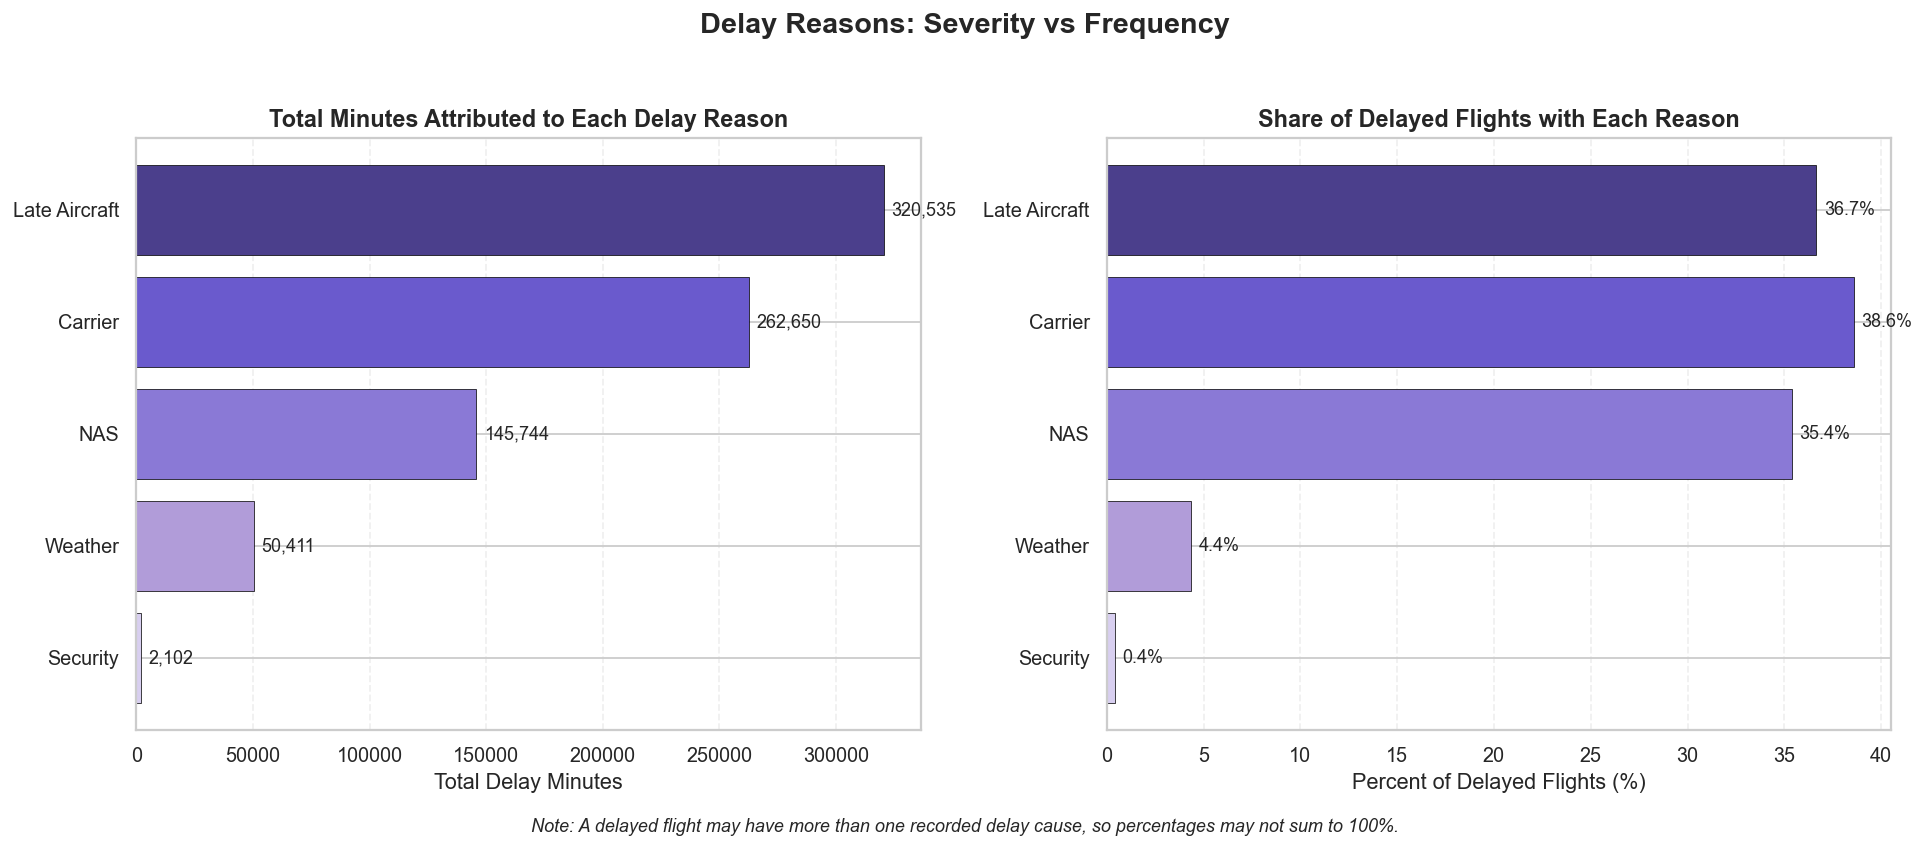

In [778]:
# Delay reason columns
delay_reason_cols = [
    "late_aircraft_delay",
    "carrier_delay",
    "nas_delay",
    "weather_delay",
    "security_delay"
]
# Keep only existing columns
delay_reason_cols = [col for col in delay_reason_cols if col in df.columns]

reason_labels = {
    "late_aircraft_delay": "Late Aircraft",
    "carrier_delay": "Carrier",
    "nas_delay": "NAS",
    "weather_delay": "Weather",
    "security_delay": "Security"
}
reason_colors = {
    "Late Aircraft": "#4B3F8C",
    "Carrier": "#6A5ACD",
    "NAS": "#8A79D6",
    "Weather": "#B19CD9",
    "Security": "#D8CFF0"
}

# Fill missing values with 0
reason_data = df[delay_reason_cols].fillna(0)

# Total delay minutes by reason
reason_minutes = reason_data.sum()

# Among delayed flights, % affected by each reason
delayed_df = df[df["IS_Delay"] == 1]
reason_share = delayed_df[delay_reason_cols].fillna(0).gt(0).mean() * 100

# Use the SAME order in both charts (sorted by total minutes)
order = reason_minutes.sort_values(ascending=False).index
reason_minutes = reason_minutes.loc[order]
reason_share = reason_share.loc[order]

# Replace column names with clean labels
reason_minutes.index = [reason_labels[col] for col in reason_minutes.index]
reason_share.index = [reason_labels[col] for col in reason_share.index]

# Matching colors in the same order
colors = [reason_colors[label] for label in reason_minutes.index]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Delay Reasons: Severity vs Frequency", fontsize=16, fontweight="bold", y=1.03)

# --- Left chart: total delay minutes ---
axes[0].barh(reason_minutes.index, reason_minutes.values, color=colors, edgecolor="black", linewidth=0.4)
axes[0].invert_yaxis()
axes[0].set_title("Total Minutes Attributed to Each Delay Reason", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Total Delay Minutes")
axes[0].set_ylabel("")
axes[0].grid(axis="x", linestyle="--", alpha=0.3)

for i, v in enumerate(reason_minutes.values):
    axes[0].text(v + reason_minutes.max() * 0.01, i, f"{v:,.0f}", va="center", fontsize=10)

# --- Right chart: % of delayed flights affected ---
axes[1].barh(reason_share.index, reason_share.values, color=colors, edgecolor="black", linewidth=0.4)
axes[1].invert_yaxis()
axes[1].set_title("Share of Delayed Flights with Each Reason", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Percent of Delayed Flights (%)")
axes[1].set_ylabel("")
axes[1].grid(axis="x", linestyle="--", alpha=0.3)

for i, v in enumerate(reason_share.values):
    axes[1].text(v + reason_share.max() * 0.01, i, f"{v:.1f}%", va="center", fontsize=10)

fig.text(
    0.5, -0.02,
    "Note: A delayed flight may have more than one recorded delay cause, so percentages may not sum to 100%.",
    ha="center", fontsize=10, style="italic"
)

plt.tight_layout()
plt.show()

## 2. Flight Volume and Delay Rate by Departure Hour
This chart compares flight volume and delay rate by departure hour. It helps show whether delay risk increases during busier parts of the day or during specific departure windows.

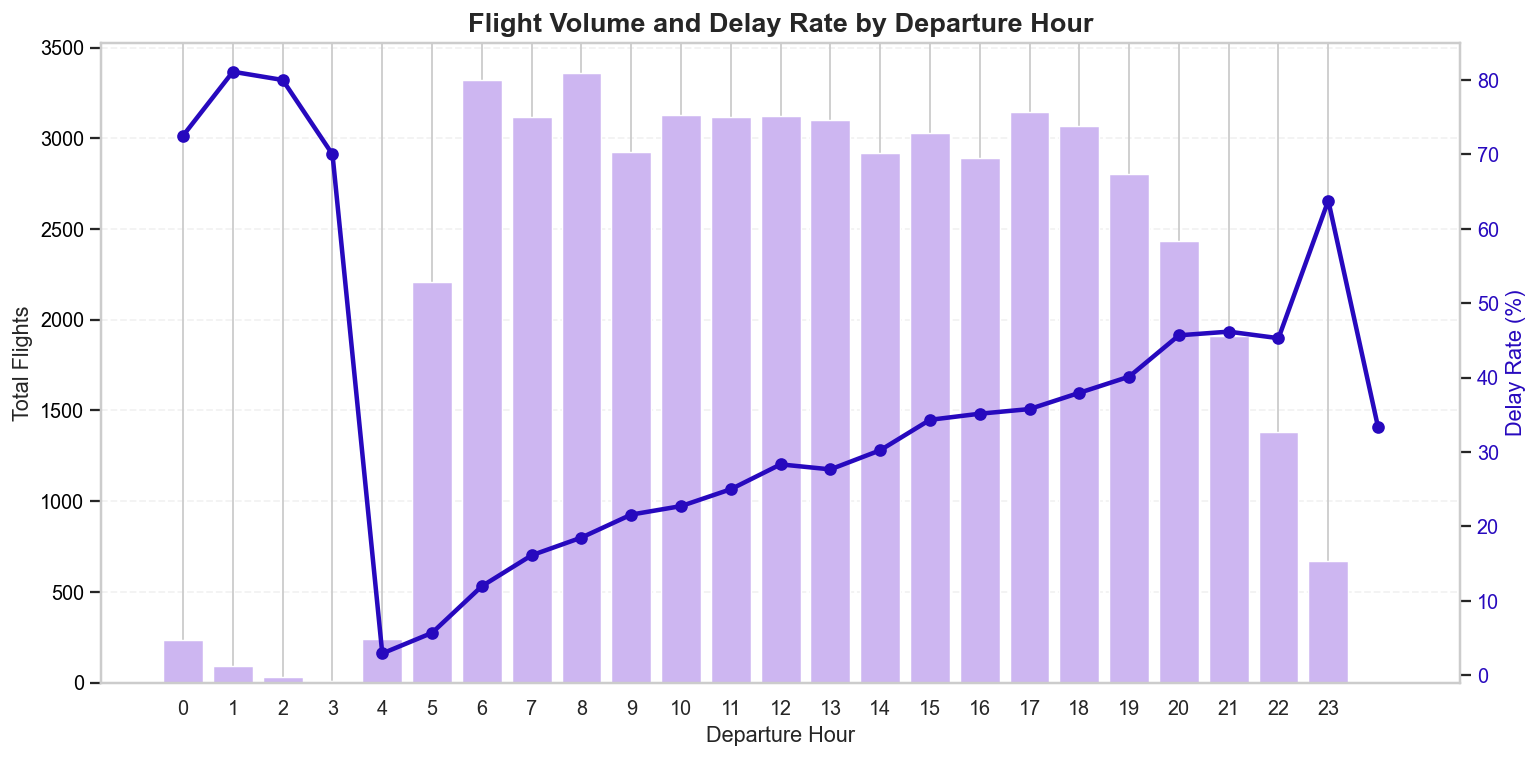

In [794]:
# Keep valid departure hours only
hourly_delay = (
    df.dropna(subset=["Departure_Hour"])
      .assign(Departure_Hour=lambda x: pd.to_numeric(x["Departure_Hour"], errors="coerce"))
      .dropna(subset=["Departure_Hour"])
      .groupby("Departure_Hour")["IS_Delay"]
      .agg(Total_Flights="count", Delayed_Flights="sum")
      .reset_index()
      .sort_values("Departure_Hour")
)

# Convert hour to integer for clean plotting
hourly_delay["Departure_Hour"] = hourly_delay["Departure_Hour"].astype(int)

# Delay rate as percentage
hourly_delay["Delay_Rate"] = (
    hourly_delay["Delayed_Flights"] / hourly_delay["Total_Flights"] * 100
)

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(
    hourly_delay["Departure_Hour"],
    hourly_delay["Total_Flights"],
    color="#CDB6F1",
    edgecolor="white",
    linewidth=0.8,
    label="Total Flights"
)

ax1.set_title("Flight Volume and Delay Rate by Departure Hour", fontsize=15, fontweight="bold")
ax1.set_xlabel("Departure Hour")
ax1.set_ylabel("Total Flights", )
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_xticks(range(24))
ax1.grid(axis="y", linestyle="--", alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(
    hourly_delay["Departure_Hour"],
    hourly_delay["Delay_Rate"],
    color="#2709BE",
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="Delay Rate (%)"
)

ax2.set_ylabel("Delay Rate (%)", color="#2709be")
ax2.tick_params(axis="y", labelcolor="#2709be")
ax2.grid(False)


plt.tight_layout()
plt.show()

## 3. Delay Rate by Weekday
This chart shows how delay rate changes across the week. It helps identify whether some weekdays are more delay-prone than others.

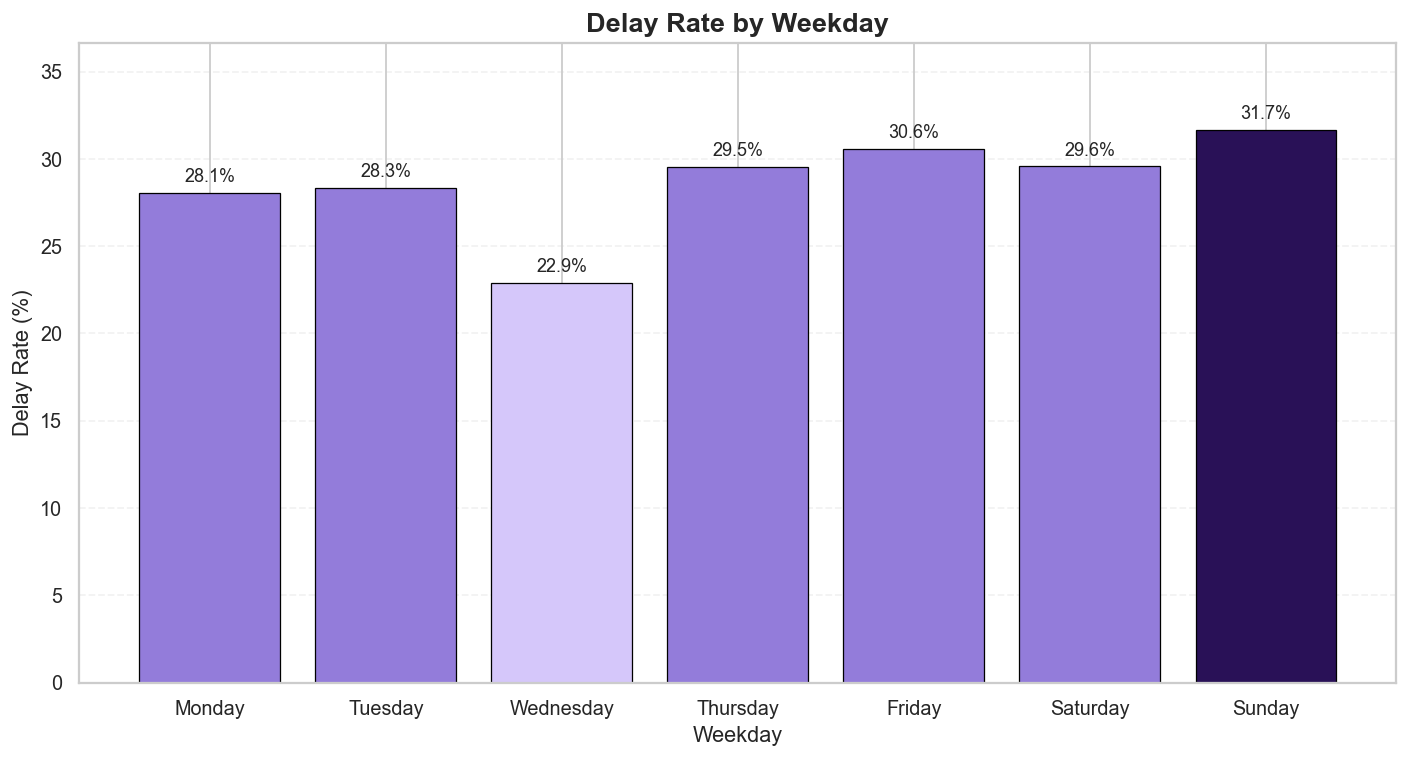

In [795]:
# Delay rate by weekday
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_delay = (
    df.groupby("Weekday")["IS_Delay"]
      .mean()
      .mul(100)
      .reindex(weekday_order)
      .reset_index()
)

# Identify highest and lowest delay days
max_day = weekday_delay.loc[weekday_delay["IS_Delay"].idxmax(), "Weekday"]
min_day = weekday_delay.loc[weekday_delay["IS_Delay"].idxmin(), "Weekday"]

# Set colors: default + highlight max and min
colors = []
for day in weekday_delay["Weekday"]:
    if day == max_day:
        colors.append("#291157")   # dark purple = highest
    elif day == min_day:
        colors.append("#D5C7FA")   # light purple = lowest
    else:
        colors.append("#937CDA")   # main purple = others

plt.figure(figsize=(11, 6))
bars = plt.bar(
    weekday_delay["Weekday"],
    weekday_delay["IS_Delay"],
    color=colors,
    edgecolor="black",
    linewidth=0.7
)

# Add value labels
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.4,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Delay Rate by Weekday", fontsize=15, weight="bold")
plt.xlabel("Weekday", fontsize=12)
plt.ylabel("Delay Rate (%)", fontsize=12)
plt.ylim(0, weekday_delay["IS_Delay"].max() + 5)
plt.grid(axis="y", alpha=0.25, linestyle="--")
plt.tight_layout()
plt.show()

## 4. Top 10 Most Reliable Airlines
This chart ranks airlines by on time departure percentage to highlight which carriers were the most reliable overall.

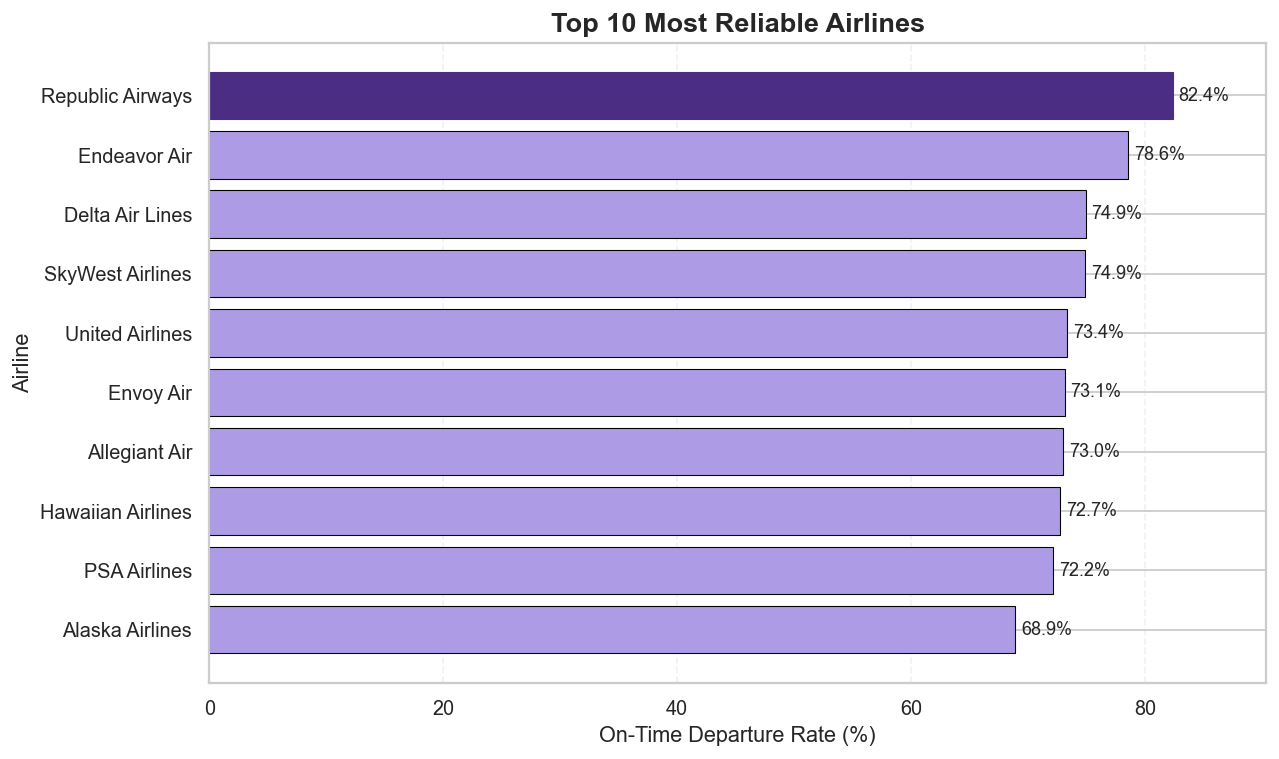

In [839]:
# Top most reliable airlines
# Reliability = on-time departure percentage

carrier_col = "op_unique_carrier"

airline_map = {
    "AA": "American Airlines",
    "AS": "Alaska Airlines",
    "B6": "JetBlue Airways",
    "DL": "Delta Air Lines",
    "F9": "Frontier Airlines",
    "G4": "Allegiant Air",
    "HA": "Hawaiian Airlines",
    "MQ": "Envoy Air",
    "NK": "Spirit Airlines",
    "OH": "PSA Airlines",
    "OO": "SkyWest Airlines",
    "UA": "United Airlines",
    "WN": "Southwest Airlines",
    "YX": "Republic Airways",
    "9E": "Endeavor Air"
}

airline_reliability = (
    df.groupby(carrier_col)["IS_Delay"]
      .agg(Total_Flights="count", Delay_Rate="mean")
      .reset_index()
)

airline_reliability["On_Time_Rate"] = (1 - airline_reliability["Delay_Rate"]) * 100
airline_reliability["Airline"] = airline_reliability[carrier_col].map(airline_map).fillna(airline_reliability[carrier_col])

top_reliable = (
    airline_reliability.sort_values("On_Time_Rate", ascending=False)
    .head(10)
    .sort_values("On_Time_Rate", ascending=True)
)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    top_reliable["Airline"],
    top_reliable["On_Time_Rate"],
    color="#AD9BE5",
    edgecolor="black",
    linewidth=0.6
)

bars[-1].set_color("#4B2E83")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=10
    )

title_n = len(top_reliable)
plt.title(f"Top {title_n} Most Reliable Airlines", fontsize=15, fontweight="bold")
plt.xlabel("On-Time Departure Rate (%)")
plt.ylabel("Airline")
plt.xlim(0, top_reliable["On_Time_Rate"].max() + 8)
plt.grid(axis="x", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()

# Weather Based EDA

In [840]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})


df   = pd.read_csv('./merged_flights.csv', low_memory=False)
             
df_weather_delayed = df[(df['IS_Delay'] == 1) & (df['weather_delay'] > 0)].copy()  

total_wx_delayed    = len(df_weather_delayed)

print(f'Weather-caused delays  (weather_delay>0): {total_wx_delayed:>10,}  ({total_wx_delayed/total_delayed*100:.1f}% of delayed)')

Weather-caused delays  (weather_delay>0):        665  (4.4% of delayed)


### 1. How Many Delayed Flights Were Weather-Caused?

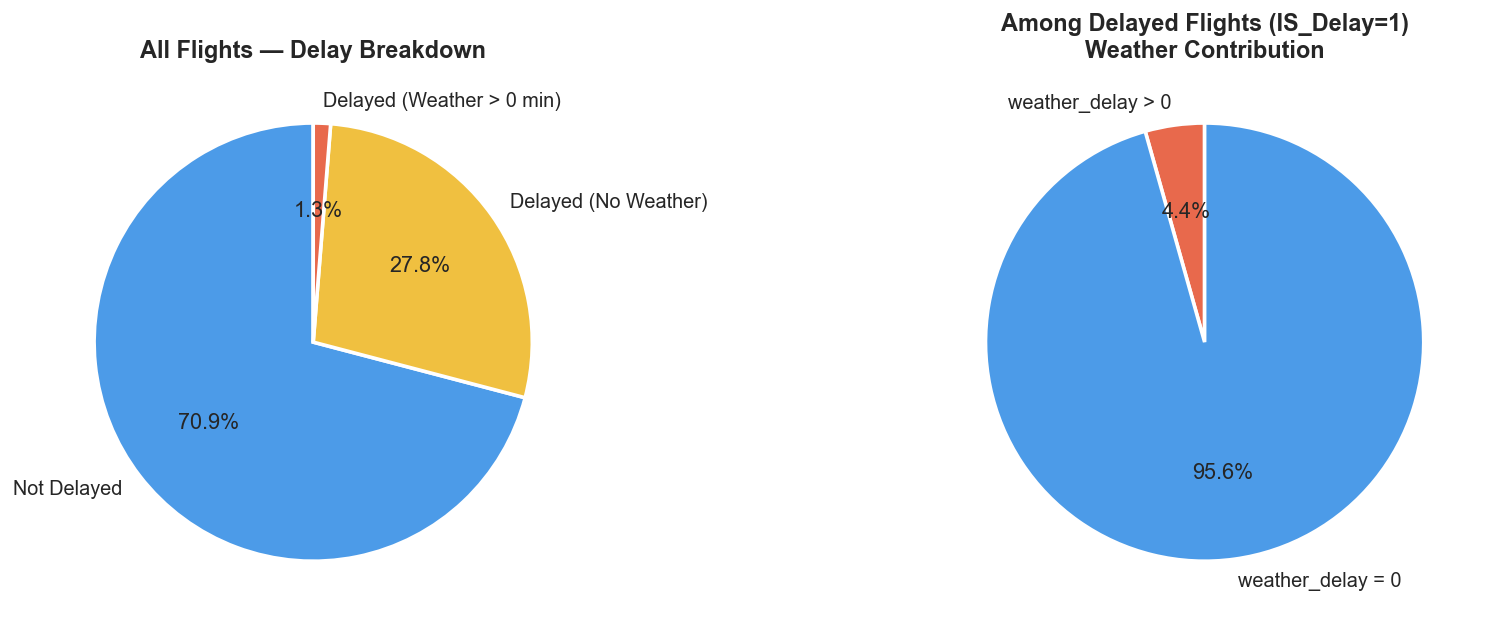

In [841]:
not_delayed         = total - total_delayed
delayed_no_weather  = total_delayed - total_wx_delayed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All flights breakdown
axes[0].pie(
    [not_delayed, delayed_no_weather, total_wx_delayed],
    labels=['Not Delayed', 'Delayed (No Weather)', 'Delayed (Weather > 0 min)'],
    autopct='%1.1f%%',
    colors=['#4C9BE8', '#F0C040', '#E8694C'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('All Flights — Delay Breakdown', fontsize=13, fontweight='bold')

# Among delayed only: weather > 0 vs not
axes[1].pie(
    [total_wx_delayed, delayed_no_weather],
    labels=['weather_delay > 0', 'weather_delay = 0'],
    autopct='%1.1f%%',
    colors=['#E8694C', '#4C9BE8'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Among Delayed Flights (IS_Delay=1)\nWeather Contribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 2. Weather-Caused Delay Rate by Season

        total_flights  total_delayed  wx_delayed  wx_pct_of_all  wx_pct_of_delayed
Season                                                                            
Winter          12368           3539         188           1.52               5.31
Spring          13196           4068         162           1.23               3.98
Summer          13629           4793         234           1.72               4.88
Fall            13084           2805          81           0.62               2.89


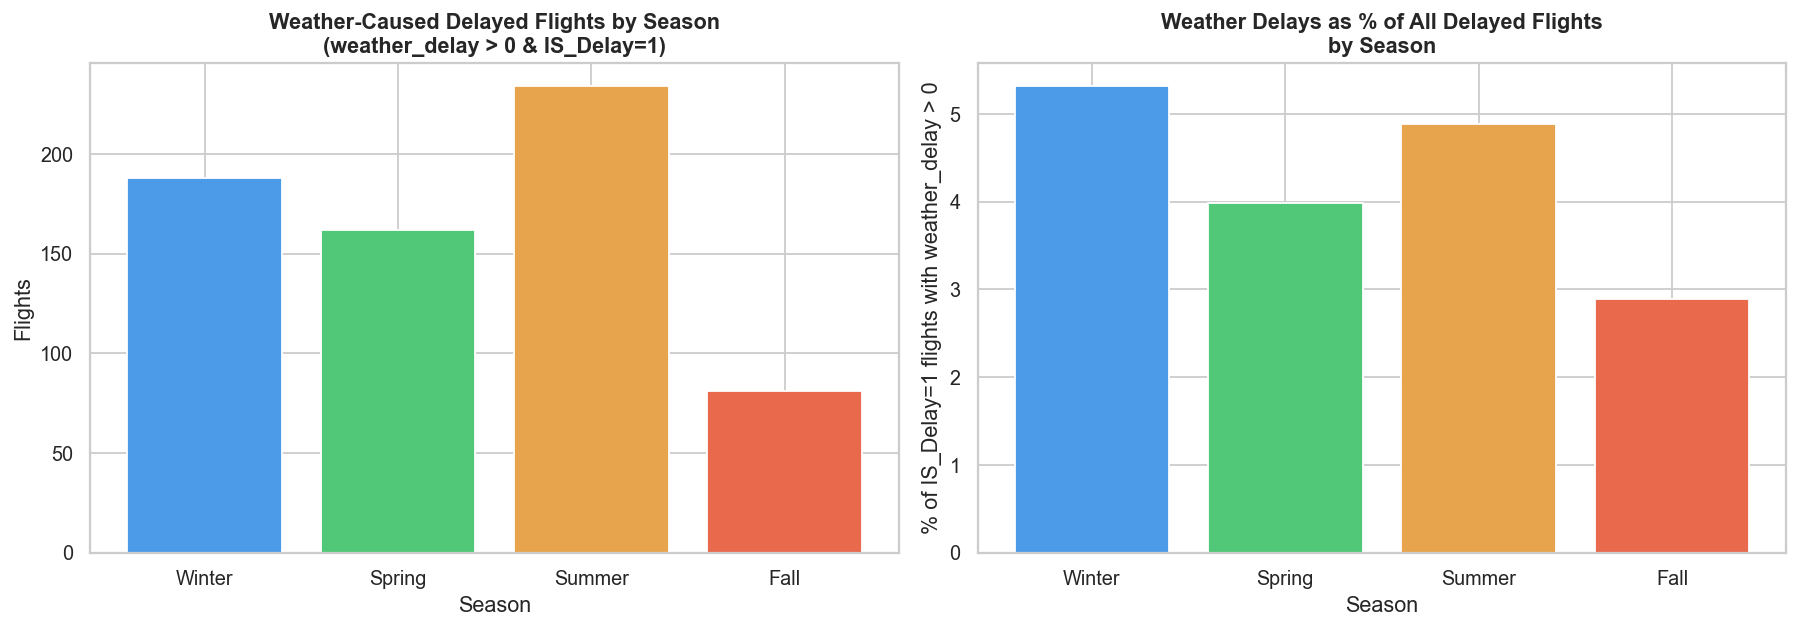

In [842]:
season_order  = ['Winter', 'Spring', 'Summer', 'Fall']
season_colors = ['#4C9BE8', '#50C878', '#E8A44C', '#E8694C']

season_stats = (
    df.groupby('Season')
    .agg(
        total_flights   =('IS_Delay',       'count'),
        total_delayed   =('IS_Delay',       'sum'),
        wx_delayed      =('weather_delay',  lambda x: (x > 0).sum())
    )
    .reindex(season_order)
)
season_stats['wx_pct_of_all']     = season_stats['wx_delayed'] / season_stats['total_flights']  * 100
season_stats['wx_pct_of_delayed'] = season_stats['wx_delayed'] / season_stats['total_delayed']  * 100

print(season_stats.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(season_stats.index, season_stats['wx_delayed'],
            color=season_colors, edgecolor='white')
axes[0].set_title('Weather-Caused Delayed Flights by Season\n(weather_delay > 0 & IS_Delay=1)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Flights')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(season_stats.index, season_stats['wx_pct_of_delayed'],
            color=season_colors, edgecolor='white')
axes[1].set_title('Weather Delays as % of All Delayed Flights\nby Season', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% of IS_Delay=1 flights with weather_delay > 0')

for ax in axes:
    ax.set_xlabel('Season')
plt.tight_layout()
plt.show()

### 3. Monthly Trend

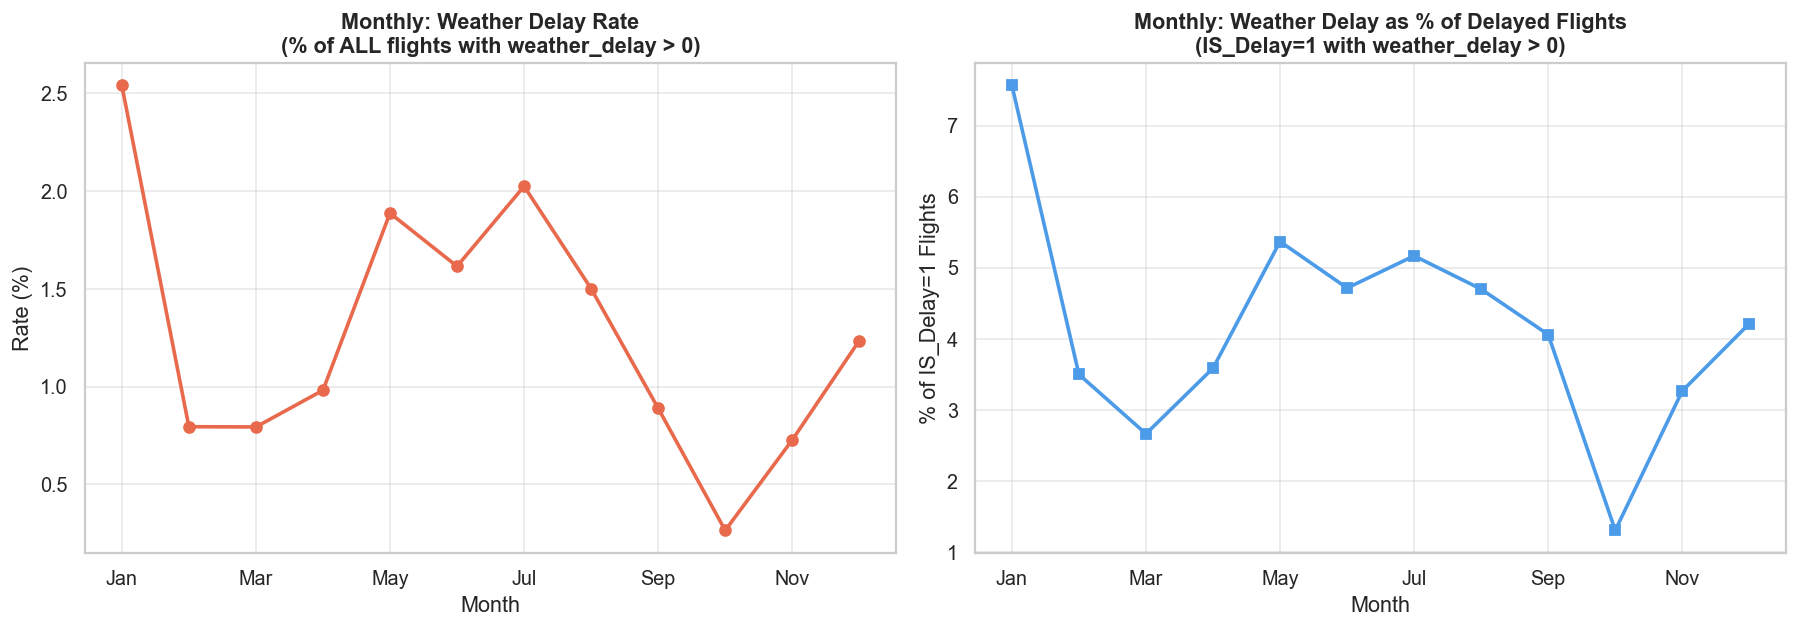

In [843]:
monthly = (
    df.groupby('month')
    .agg(
        total_flights   =('IS_Delay',      'count'),
        total_delayed   =('IS_Delay',      'sum'),
        wx_delayed      =('weather_delay', lambda x: (x > 0).sum())
    )
)
monthly['wx_pct_of_all']     = monthly['wx_delayed'] / monthly['total_flights']  * 100
monthly['wx_pct_of_delayed'] = monthly['wx_delayed'] / monthly['total_delayed']  * 100

month_names   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly.index = [month_names[i-1] for i in monthly.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly['wx_pct_of_all'].plot(kind='line', marker='o', ax=axes[0], color='#E8694C', linewidth=2)
axes[0].set_title('Monthly: Weather Delay Rate\n(% of ALL flights with weather_delay > 0)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Rate (%)')
axes[0].set_xlabel('Month')
axes[0].grid(True, alpha=0.4)

monthly['wx_pct_of_delayed'].plot(kind='line', marker='s', ax=axes[1], color='#4C9BE8', linewidth=2)
axes[1].set_title('Monthly: Weather Delay as % of Delayed Flights\n(IS_Delay=1 with weather_delay > 0)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('% of IS_Delay=1 Flights')
axes[1].set_xlabel('Month')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### 4. Top Cities with Most Weather-Caused Delays

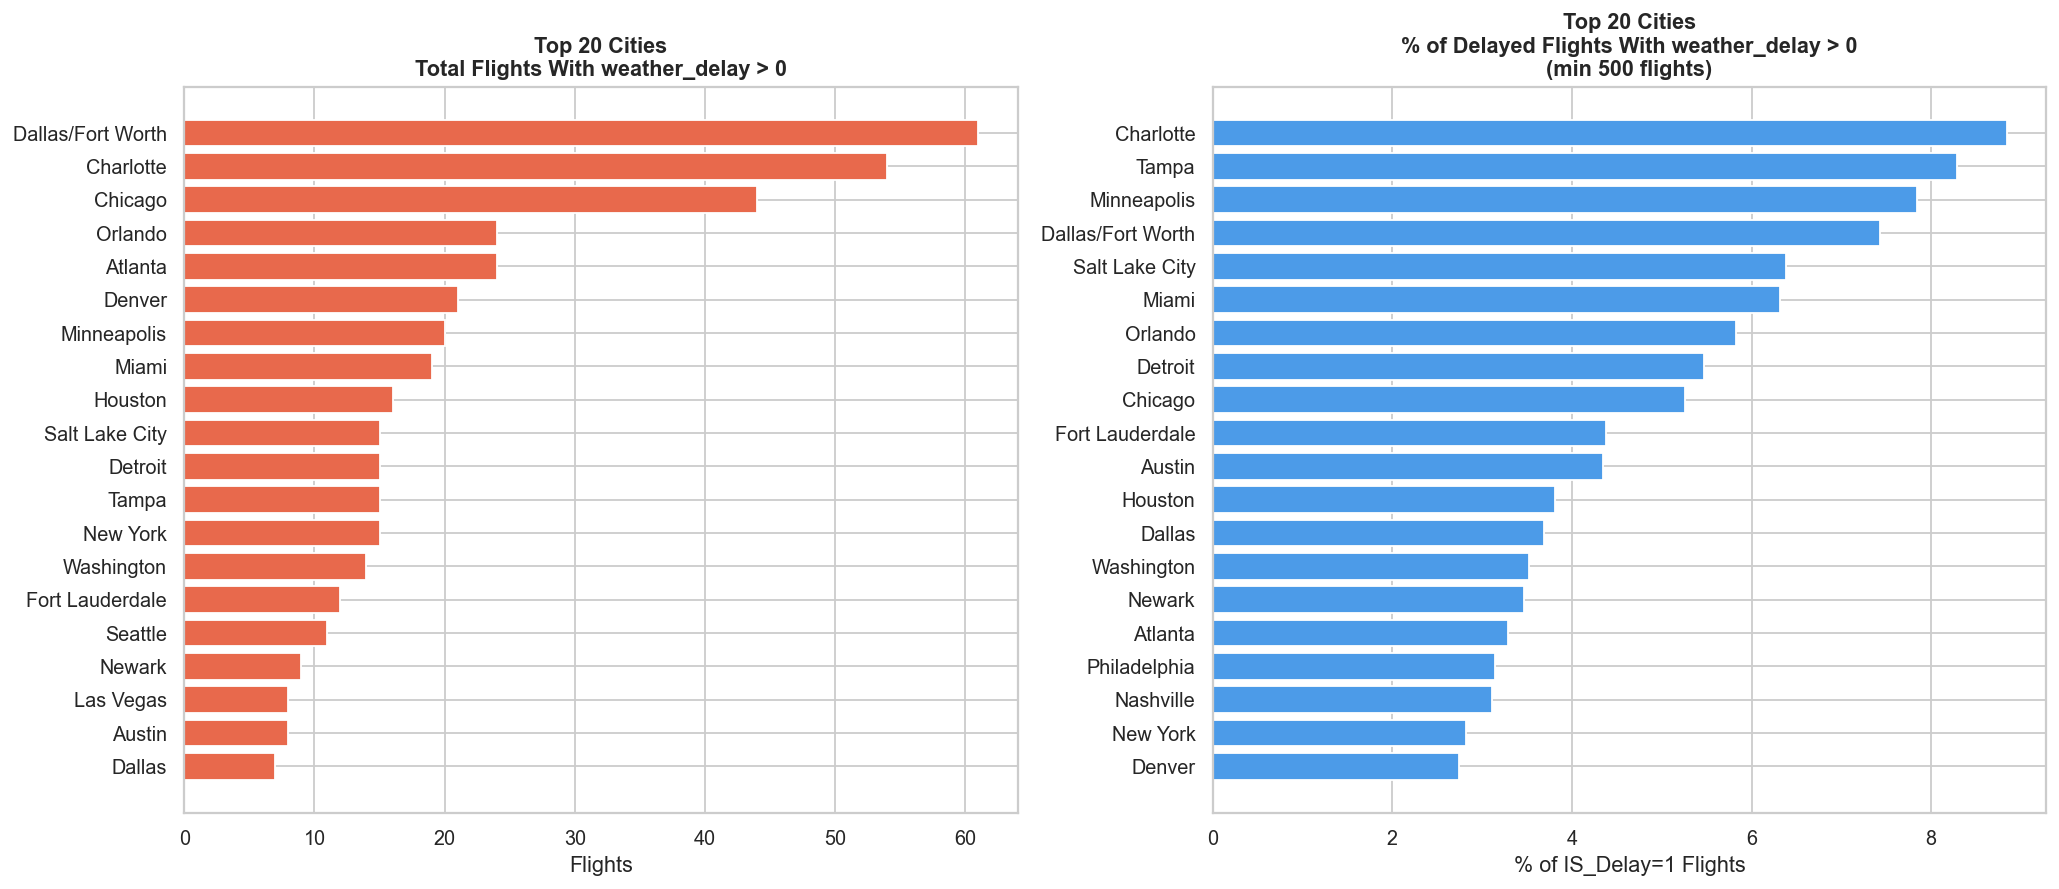

In [844]:
city_stats = (
    df.groupby('origin_city')
    .agg(
        total_flights   =('IS_Delay',      'count'),
        total_delayed   =('IS_Delay',      'sum'),
        wx_delayed      =('weather_delay', lambda x: (x > 0).sum())
    )
    .assign(
        wx_pct_of_flights  = lambda x: x['wx_delayed'] / x['total_flights']  * 100,
        wx_pct_of_delayed  = lambda x: x['wx_delayed'] / x['total_delayed']  * 100
    )
    .sort_values('wx_delayed', ascending=False)
)

top20      = city_stats.head(20)
top20_rate = (city_stats[city_stats['total_flights'] >= 500]
              .sort_values('wx_pct_of_delayed', ascending=False).head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top20.index[::-1], top20['wx_delayed'][::-1], color='#E8694C', edgecolor='white')
axes[0].set_title('Top 20 Cities\nTotal Flights With weather_delay > 0', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Flights')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(top20_rate.index[::-1], top20_rate['wx_pct_of_delayed'][::-1], color='#4C9BE8', edgecolor='white')
axes[1].set_title('Top 20 Cities\n% of Delayed Flights With weather_delay > 0\n(min 500 flights)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('% of IS_Delay=1 Flights')

plt.tight_layout()
plt.show()

# Models

In [845]:
import pandas as pd
df = pd.read_csv("merged_flights.csv",low_memory=False)
#df['IS_Delay'] = (df['arr_delay'] > 15).astype(int)

In [846]:
df

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city,origin_state,...,Departure_Hour,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,Hour,Month_Number,Month_Name,Weekday,Weather_Data_Present
0,2024,1,1,1,2024-01-01,OO,4099.0,LAX,Los Angeles,California,...,9,-1.646177,66.507603,1.481798,18.518889,8.0,1.0,January,Monday,Yes
1,2024,1,1,1,2024-01-01,UA,599.0,DEN,Denver,Colorado,...,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
2,2024,1,1,1,2024-01-01,WN,2539.0,BWI,Baltimore,Maryland,...,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
3,2024,1,1,1,2024-01-01,HA,295.0,OGG,Kahului,Hawaii,...,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
4,2024,1,1,1,2024-01-01,UA,348.0,OGG,Kahului,Hawaii,...,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52272,2024,12,31,2,2024-12-31,YX,3586.0,MSN,Madison,Wisconsin,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
52273,2024,12,31,2,2024-12-31,OO,5717.0,MSN,Madison,Wisconsin,...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
52274,2024,12,31,2,2024-12-31,AA,1482.0,CLT,Charlotte,North Carolina,...,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
52275,2024,12,31,2,2024-12-31,OO,5377.0,DEN,Denver,Colorado,...,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


## Baseline model

Predict majority class of no delay

In [847]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = df['IS_Delay']
y_pred_baseline = [0] * len(df)

print(df['IS_Delay'].value_counts())
baseline_accuracy = (df['IS_Delay'] == 0).sum() / len(df)
print(f"Accuracy: {baseline_accuracy:.3f}")
print(f"Precision: {precision_score(y_true, y_pred_baseline, zero_division=0):.3f}")
print(f"Recall: {recall_score(y_true, y_pred_baseline, zero_division=0):.3f}")
print(f"F1 score: {f1_score(y_true, y_pred_baseline, zero_division=0):.3f}")

IS_Delay
0    37072
1    15205
Name: count, dtype: int64
Accuracy: 0.709
Precision: 0.000
Recall: 0.000
F1 score: 0.000


## Correlation of target with selected features

In [848]:
from sklearn.preprocessing import LabelEncoder
df_1 = df.copy()

cols = ["month","day_of_month","day_of_week","op_unique_carrier","origin_city","origin_state",
    "dep_time","Season","Departure_Hour","IS_Delay", "Precipitation_mm"]

df_1 = df_1[cols].dropna()

#encoding
for col in ["op_unique_carrier", "origin_city", "origin_state", "Season"]:
    df_1[col] = LabelEncoder().fit_transform(df_1[col])


corr = df_1.corr(numeric_only=True)
print(corr["IS_Delay"].sort_values(ascending=False))

IS_Delay             1.000000
Departure_Hour       0.209346
dep_time             0.208998
origin_state         0.044465
day_of_week          0.033866
op_unique_carrier    0.001576
month                0.000687
Precipitation_mm    -0.002306
day_of_month        -0.014774
Season              -0.018314
origin_city         -0.020361
Name: IS_Delay, dtype: float64


# Simple decision tree bagging

In [849]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix


df_1 = df.copy()
cols = ["month","day_of_month","day_of_week", "op_unique_carrier","origin_city","origin_state","Precipitation_mm",
    "dep_time","Season","Departure_Hour","IS_Delay"]
df_1 = df_1[cols].dropna()

# Encode all at once, 
# but we don't need a label encoder for decision tree...
# removing it and replacing with category codes
 
#le = LabelEncoder()
#for col in ["op_unique_carrier", "origin_city", "origin_state", "Season"]:
    #df_1[col] = le.fit_transform(df_1[col])
for col in ["op_unique_carrier", "origin_city", "origin_state", "Season"]:
    df_1[col] = df_1[col].astype('category').cat.codes
print(len(df_1))
X = df_1.drop("IS_Delay", axis=1)
y = df_1["IS_Delay"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
tree = DecisionTreeClassifier()

# Bagging with 5 trees
model_bag = BaggingClassifier(estimator=tree,n_estimators=5)


model_bag.fit(X_train, y_train)
y_pred = model_bag.predict(X_test)
y_proba = model_bag.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"TN: {cm[0,0]:5d}  FP: {cm[0,1]:5d}")
print(f"FN: {cm[1,0]:5d}  TP: {cm[1,1]:5d}")

4265
Accuracy: 0.674
Precision: 0.382
Recall: 0.273
F1 Score: 0.319
ROC-AUC: 0.592
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       615
           1       0.38      0.27      0.32       238

    accuracy                           0.67       853
   macro avg       0.56      0.55      0.55       853
weighted avg       0.65      0.67      0.66       853


Confusion Matrix:
TN:   510  FP:   105
FN:   173  TP:    65


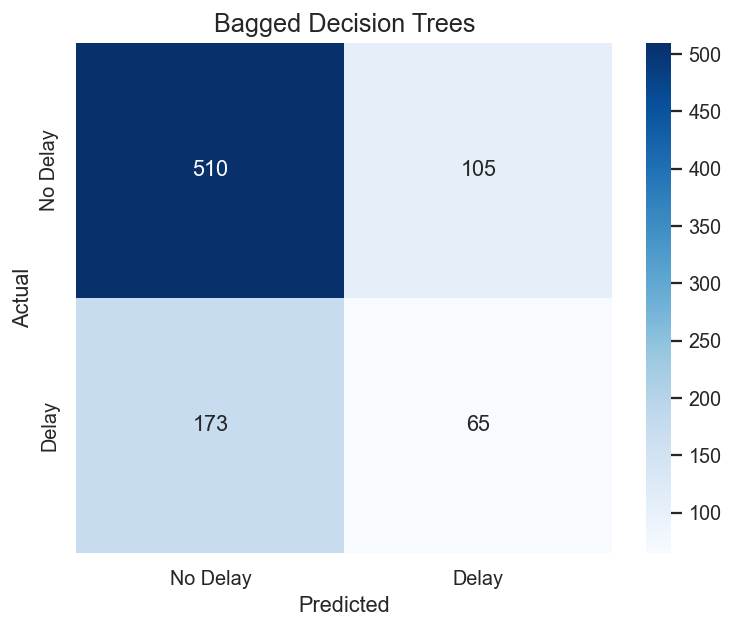

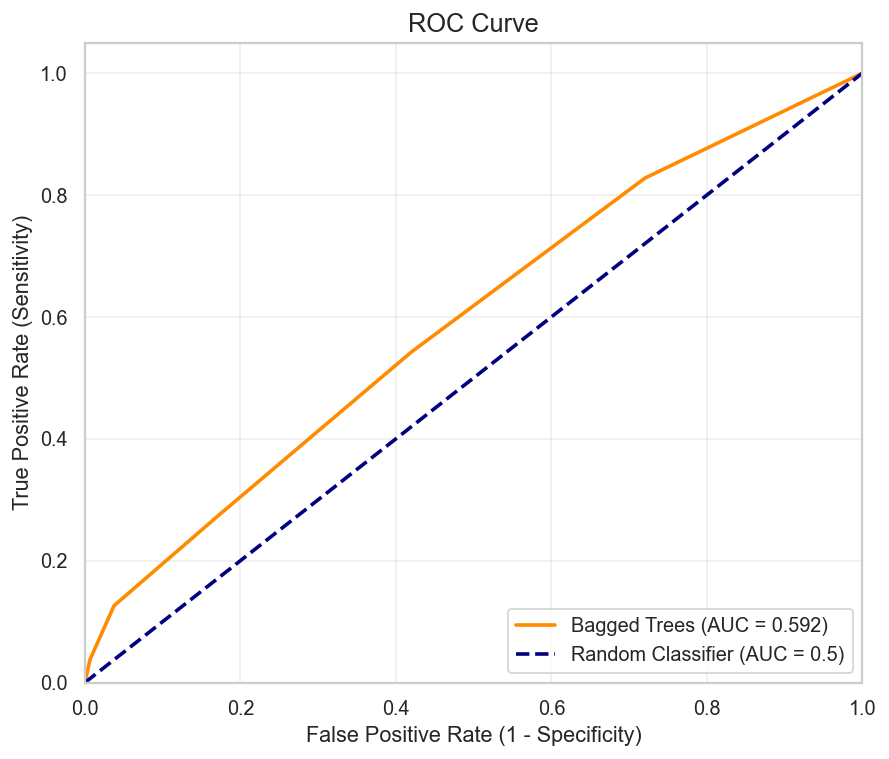

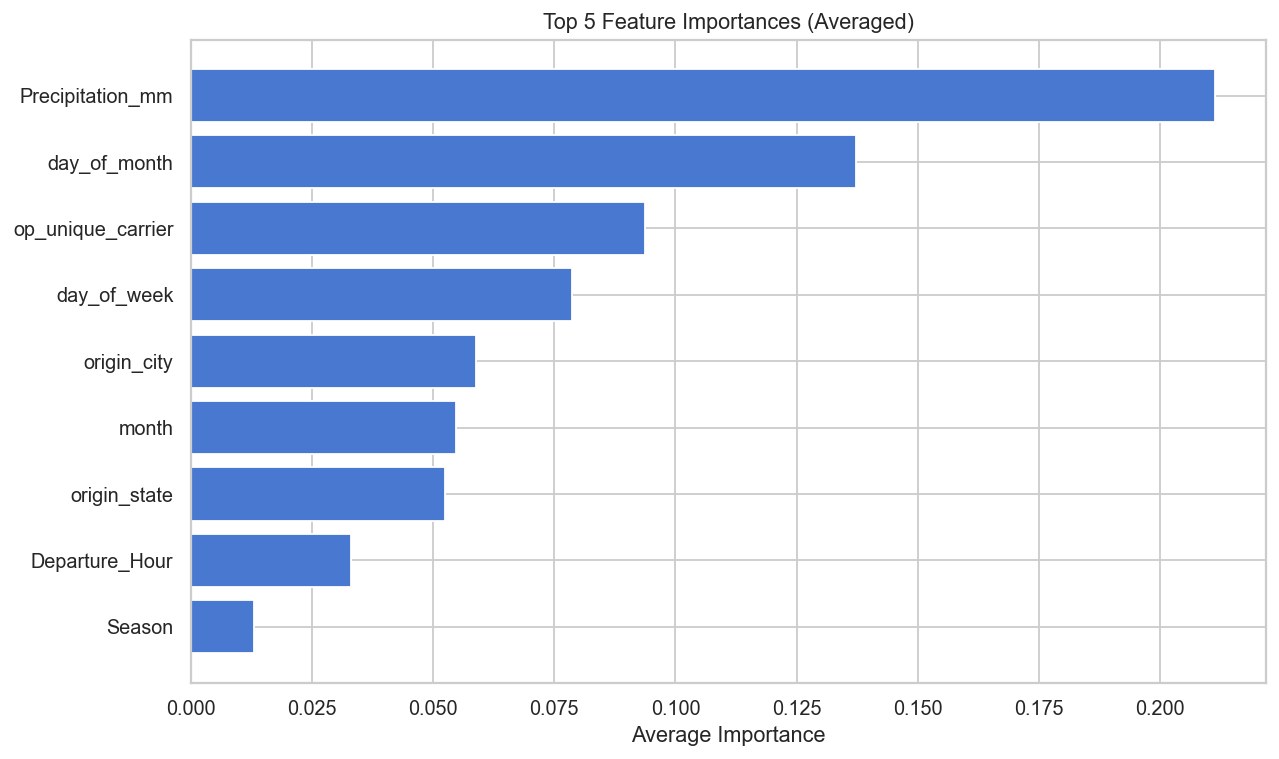

In [850]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import numpy as np
# conf matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Delay', 'Delay'],yticklabels=['No Delay', 'Delay'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Bagged Decision Trees', fontsize=14)
plt.tight_layout()
plt.show()



# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'Bagged Trees (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


all_trees = model_bag.estimators_
# Average 
avg_importances = np.mean([tree.feature_importances_ for tree in all_trees], axis=0)
features = X.columns

# Create dataframe for easy viewing
importance_df = pd.DataFrame({'feature': features,'importance': avg_importances}).sort_values('importance', ascending=False)
importance_df = importance_df[importance_df['feature'] != 'dep_time']


# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df.head(10)['feature'], importance_df.head(10)['importance'])
plt.xlabel('Average Importance')
plt.title('Top 5 Feature Importances (Averaged)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# KNN

In [851]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Create encoding for hour, month, day of week
def add_cyclical_features(df):
    df_cyclical = df.copy()
    
    df_cyclical['hour_sin'] = np.sin(2 * np.pi * df_cyclical['Departure_Hour'] / 24)
    df_cyclical['hour_cos'] = np.cos(2 * np.pi * df_cyclical['Departure_Hour'] / 24)
    df_cyclical['month_sin'] = np.sin(2 * np.pi * df_cyclical['month'] / 12)
    df_cyclical['month_cos'] = np.cos(2 * np.pi * df_cyclical['month'] / 12)
    df_cyclical['dow_sin'] = np.sin(2 * np.pi * df_cyclical['day_of_week'] / 7)
    df_cyclical['dow_cos'] = np.cos(2 * np.pi * df_cyclical['day_of_week'] / 7)
    
    # Drop original
    df_cyclical = df_cyclical.drop(['Departure_Hour', 'month', 'day_of_week'], axis=1)
    
    return df_cyclical

df_1 = df.copy()


# Select columns (keeping dep_time as is for now)
cols = ["month", "day_of_month", "day_of_week", "op_unique_carrier", 
        "origin_city", "origin_state", "dep_time", "Season", 
        "Departure_Hour", "IS_Delay", "Precipitation_mm"]
df_1 = df_1[cols].dropna()
# use subset maybe for demo?
# for some reason it takes way too long so I'm doing only 100k
df_1 = df_1.sample(1000, random_state=811)
print(len(df.columns))
print(f"The dataset size for KNN is: {len(df_1)}")

df_1 = add_cyclical_features(df_1)

# Convert departure time into minutes
df_1['dep_time_minutes'] = (df_1['dep_time'] // 100) * 60 + (df_1['dep_time'] % 100)
df_1 = df_1.drop('dep_time', axis=1)
# One-hot encode categorical
df_1 = pd.get_dummies(df_1, columns=["op_unique_carrier", "origin_city", "origin_state", "Season"], drop_first=True)

X = df_1.drop("IS_Delay", axis=1)
print(len(df.columns))
y = df_1["IS_Delay"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=811)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN and grid search (same as your original)
knn = KNeighborsClassifier()
param_grid = {"n_neighbors": [5, 10, 15, 20],"weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]}

grid = GridSearchCV(knn, param_grid, cv=5, return_train_score=True)

# data is split inside fit for cross validations, 5 folds
grid.fit(X_train, y_train)

results = pd.DataFrame(grid.cv_results_)
results = results[["param_n_neighbors", "param_weights", "param_metric", "mean_test_score"]]
results = results.sort_values(by="mean_test_score", ascending=False)

print(results)
print("\nBest Parameters:", grid.best_params_)
print(f"Best CV Score: {grid.best_score_:.4f}")

# Optional: Evaluate on test set
y_pred = grid.predict(X_test)
print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

48
The dataset size for KNN is: 1000
48
    param_n_neighbors param_weights param_metric  mean_test_score
14                 20       uniform    manhattan          0.69500
6                  20       uniform    euclidean          0.69125
7                  20      distance    euclidean          0.68500
10                 10       uniform    manhattan          0.68125
2                  10       uniform    euclidean          0.67750
12                 15       uniform    manhattan          0.67625
4                  15       uniform    euclidean          0.67500
5                  15      distance    euclidean          0.67375
15                 20      distance    manhattan          0.67375
13                 15      distance    manhattan          0.67250
11                 10      distance    manhattan          0.66625
3                  10      distance    euclidean          0.65750
8                   5       uniform    manhattan          0.64000
0                   5       uniform 

## Analysis of best KNN

In [852]:
best_knn = KNeighborsClassifier(n_neighbors=20, weights='uniform', metric='manhattan')
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1Score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion matrix:")
print(f"TN: {cm[0,0]:5d}  FP: {cm[0,1]:5d}")
print(f"FN: {cm[1,0]:5d}  TP: {cm[1,1]:5d}")

Accuracy:  0.790
Precision: 0.833
Recall:  0.109
F1Score: 0.192
ROC-AUC: 0.566
              precision    recall  f1-score   support

           0       0.79      0.99      0.88       154
           1       0.83      0.11      0.19        46

    accuracy                           0.79       200
   macro avg       0.81      0.55      0.54       200
weighted avg       0.80      0.79      0.72       200


Confusion matrix:
TN:   153  FP:     1
FN:    41  TP:     5


## Hyperparameter tuning results for KNN

Results: 
        param_n_neighbors param_weights param_metric  mean_test_score

**14                 20       uniform    manhattan         0.712573 - best model**

6                  20       uniform    euclidean         0.709388

10                 10       uniform    manhattan         0.708628

12                 15       uniform    manhattan         0.707416

15                 20      distance    manhattan         0.706505

7                  20      distance    euclidean         0.706201

13                 15      distance    manhattan         0.706051

4                  15       uniform    euclidean         0.704686

2                  10       uniform    euclidean         0.704229

5                  15      distance    euclidean         0.701956

11                 10      distance    manhattan         0.695585

3                  10      distance    euclidean         0.688759

8                   5       uniform    manhattan         0.676929

9                   5      distance    manhattan         0.674350

0                   5       uniform    euclidean         0.673287

1                   5      distance    euclidean         0.671922